# Defter 2: AUTSL Veri Seti - Veri Isleme ve Normalizasyon

## Amac
Bu defterin amaci, Mediapipe araciligiyla cikarilmis ham iskelet verilerini (Long Format Parquet dosyalari) egitim icin uygun tensor yapisina (NumPy dizileri) donusturmektir.

### Veri Yapisi
- **Parquet Dosyalari**: `{split}/{participant_id}/{sequence_id}.parquet`
- **CSV Dosyalari**: `{split}.csv` - Icerik: `path`, `participant_id`, `sequence_id`, `sign`
- **Not**: Klasor adi `participant_id` degerini temsil eder; sinif etiketi (`sign`) yalnizca CSV dosyasinda bulunmaktadir.

### Uygulanan Islem Adimlari
1. **Parquet Okuma**: Long Format yapisindan `(Frames, 543, 3)` boyutlu matrise donusum
2. **Isaretci Secimi (Landmark Selection)**: 543 noktadan en anlamli 85 noktanin secilmesi (eller, dudaklar, omuzlar)
3. **NaN Isleme**: Eksik degerlerin interpolasyon ile doldurulmasi
4. **Uzamsal Normalizasyon (Spatial Normalization)**: Burun noktasina gore bagilastirma ve omuz mesafesiyle olceklendirme
5. **Zamansal Yeniden Boyutlandirma (Temporal Resizing)**: Tum orneklerin 80 kareye esitlenmesi
6. **Kayit**: Her bolum (split) icin ayri `.npy` dosyasi olarak kayit

### Veri Seti Bilgileri
- **225 sinif (sign)**: Turk Isaret Dili isaretleri
- **43 katilimci (participant)**: Isaretleri gerceklestiren bireyler
- **Train**: ~28.130 ornek | **Val**: ~4.416 ornek | **Test**: ~3.739 ornek

In [1]:
import pandas as pd
import numpy as np
import os
import glob
import gc
import time
from tqdm.notebook import tqdm
import tensorflow as tf
import matplotlib.pyplot as plt

# =============================================================================
# Yapilandirma (Configuration)
# =============================================================================

BASE_INPUT_DIR = "/kaggle/input/austl-processed-dataset-mediapipe-landmarks/AUSTL_processed_landmark"
OUTPUT_DIR = "/kaggle/working/AUTSL_Full_Processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_FRAMES = 80
NUM_CLASSES = 225   # AUTSL veri setindeki sinif sayisi

SPLITS = ['train', 'val', 'test']

print(f"Girdi Dizini:  {BASE_INPUT_DIR}")
print(f"Cikti Dizini:  {OUTPUT_DIR}")
print(f"Hedef Kare Sayisi: {TARGET_FRAMES}")
print(f"Sinif Sayisi: {NUM_CLASSES}")

2026-02-10 10:53:18.056374: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770720798.265132      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770720798.325322      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770720798.805620      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770720798.805667      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770720798.805670      17 computation_placer.cc:177] computation placer alr

Girdi Dizini:  /kaggle/input/austl-processed-dataset-mediapipe-landmarks/AUSTL_processed_landmark
Cikti Dizini:  /kaggle/working/AUTSL_Full_Processed
Hedef Kare Sayisi: 80
Sinif Sayisi: 225


## 1. CSV Meta Verilerinin Yuklenmesi ve Dogrulanmasi
Sinif etiketleri yalnizca CSV dosyalarinda yer almaktadir; klasor adlari etiket bilgisi icermemektedir.

In [2]:
csv_data = {}

print("=" * 60)
print("CSV Meta Verilerinin Yuklenmesi")
print("=" * 60)

for split in SPLITS:
    csv_path = os.path.join(BASE_INPUT_DIR, f"{split}.csv")
    df = pd.read_csv(csv_path)
    csv_data[split] = df
    
    print(f"\n[{split.upper()}]")
    print(f"   Satir Sayisi: {len(df)}")
    print(f"   Sutunlar: {list(df.columns)}")
    print(f"   Siniflar (signs): {df['sign'].nunique()} benzersiz (aralik: {df['sign'].min()}-{df['sign'].max()})")
    print(f"   Katilimcilar: {df['participant_id'].nunique()} benzersiz")
    print(f"   Ornek dosya yolu: {df['path'].iloc[0]}")
    print(f"   Ilk 3 satir:")
    display(df.head(3))

CSV Meta Verilerinin Yuklenmesi

[TRAIN]
   Satir Sayisi: 28141
   Sutunlar: ['Unnamed: 0', 'path', 'participant_id', 'sequence_id', 'sign']
   Siniflar (signs): 226 benzersiz (aralik: 0-225)
   Katilimcilar: 31 benzersiz
   Ornek dosya yolu: train/0/1.parquet
   Ilk 3 satir:


,Unnamed: 0,path,participant_id,sequence_id,sign
0,0,train/0/1.parquet,0,1,41
1,1,train/0/2.parquet,0,2,104
2,2,train/0/3.parquet,0,3,205



[VAL]
   Satir Sayisi: 4418
   Sutunlar: ['Unnamed: 0', 'path', 'participant_id', 'sequence_id', 'sign']
   Siniflar (signs): 226 benzersiz (aralik: 0-225)
   Katilimcilar: 6 benzersiz
   Ornek dosya yolu: val/1/1.parquet
   Ilk 3 satir:


,Unnamed: 0,path,participant_id,sequence_id,sign
0,0,val/1/1.parquet,1,1,136
1,1,val/1/2.parquet,1,2,130
2,2,val/1/3.parquet,1,3,139



[TEST]
   Satir Sayisi: 3742
   Sutunlar: ['Unnamed: 0', 'path', 'participant_id', 'sequence_id', 'sign']
   Siniflar (signs): 226 benzersiz (aralik: 0-225)
   Katilimcilar: 6 benzersiz
   Ornek dosya yolu: test/34/1.parquet
   Ilk 3 satir:


,Unnamed: 0,path,participant_id,sequence_id,sign
0,0,test/34/1.parquet,34,1,133
1,1,test/34/2.parquet,34,2,61
2,2,test/34/3.parquet,34,3,32


## 2. Isaretci Indekslerinin Tanimlanmasi (Landmark Indices)
Toplam 543 isaretci noktasindan anlamli 85 nokta secilmektedir.

In [3]:
# Dudak isaretcileri (40 nokta)
LIPS_IDXS0 = np.array([
    61, 185, 40, 39, 37, 0, 267, 269, 270, 409,
    291, 146, 91, 181, 84, 17, 314, 405, 321, 375,
    78, 191, 80, 81, 82, 13, 312, 311, 310, 415,
    95, 88, 178, 87, 14, 317, 402, 318, 324, 308,
])

# Vucut referans noktalari: 11=Sol Omuz, 12=Sag Omuz, 0=Burun
POSE_IDXS0 = np.array([11, 12, 0])

# 543 isaretci duzeni icindeki global indeksler
LH_GLOBAL = np.arange(501, 522)       # 21 sol el noktasi
RH_GLOBAL = np.arange(522, 543)       # 21 sag el noktasi
LIPS_GLOBAL = 33 + LIPS_IDXS0        # 40 dudak noktasi
POSE_REF_GLOBAL = POSE_IDXS0          # 3 vucut referans noktasi

KEEP_INDICES = np.concatenate([LH_GLOBAL, RH_GLOBAL, LIPS_GLOBAL, POSE_REF_GLOBAL])
NUM_SELECTED_POINTS = len(KEEP_INDICES)  # 85

print(f"Secilen nokta sayisi: {NUM_SELECTED_POINTS}")
print(f"   Sol El: {len(LH_GLOBAL)}, Sag El: {len(RH_GLOBAL)}, Dudaklar: {len(LIPS_GLOBAL)}, Vucut Ref: {len(POSE_REF_GLOBAL)}")

Secilen nokta sayisi: 85
   Sol El: 21, Sag El: 21, Dudaklar: 40, Vucut Ref: 3


## 3. Islem Sinifi (FeatureGen)

In [4]:
class FeatureGen:
    """
    Long Format Parquet dosyalarini okuyarak tam on isleme hattini uygulayan sinif.
    Parquet formati: frame, row_id, type, landmark_index, x, y, z
    """
    
    def __init__(self):
        self.type_map = {
            'pose':       0,
            'face':       33,
            'left_hand':  501,
            'right_hand': 522,
        }

    def read_parquet(self, path):
        """Long Format Parquet dosyasini okur ve (n_frames, 543, 3) boyutlu diziye donusturur."""
        try:
            df = pd.read_parquet(path)
        except Exception as e:
            return None
        
        if len(df) == 0:
            return None
        
        frames = sorted(df['frame'].unique())
        n_frames = len(frames)
        frame_to_idx = {f: i for i, f in enumerate(frames)}
        
        data = np.full((n_frames, 543, 3), np.nan, dtype=np.float32)
        
        # Vektorize doldurma islemi
        type_offset = df['type'].map(self.type_map).values
        global_idx = type_offset + df['landmark_index'].values
        frame_idx = df['frame'].map(frame_to_idx).values
        
        data[frame_idx, global_idx, 0] = df['x'].values.astype(np.float32)
        data[frame_idx, global_idx, 1] = df['y'].values.astype(np.float32)
        data[frame_idx, global_idx, 2] = df['z'].values.astype(np.float32)
        
        return data

    def smart_resize(self, x, target_frames=80):
        """Zamansal boyutu bilineer interpolasyon ile yeniden boyutlandirir."""
        if len(x) == target_frames:
            return x
        x_resized = tf.image.resize(
            x[None, ...],
            [target_frames, x.shape[1]],
            method='bilinear'
        )
        return x_resized.numpy()[0]

    def preprocess(self, x):
        """
        Tam on isleme hatti.
        Girdi:  (n_frames, 543, 3)
        Cikti:  (TARGET_FRAMES, 85, 3)
        """
        # 1. Onemli isaretci noktalarinin secilmesi
        x_filtered = x[:, KEEP_INDICES, :]
        
        # 2. NaN degerlerinin interpolasyonu
        x_flat = x_filtered.reshape(x_filtered.shape[0], -1)
        df_tmp = pd.DataFrame(x_flat)
        df_tmp = df_tmp.interpolate(method='linear', limit_direction='both', axis=0)
        df_tmp = df_tmp.fillna(0)
        x_filtered = df_tmp.values.reshape(x_filtered.shape[0], -1, 3)
        
        # 3. Uzamsal normalizasyon
        # [-3]=sol_omuz, [-2]=sag_omuz, [-1]=burun
        nose = x_filtered[:, -1, :]
        left_sh = x_filtered[:, -3, :]
        right_sh = x_filtered[:, -2, :]
        
        x_filtered = x_filtered - nose[:, None, :]
        
        scale = np.linalg.norm(left_sh - right_sh, axis=1)
        scale[scale == 0] = 1.0
        x_filtered = x_filtered / scale[:, None, None]
        
        # 4. Zamansal yeniden boyutlandirma
        x_final = self.smart_resize(x_filtered, TARGET_FRAMES)
        
        return x_final

print("FeatureGen sinifi tanimlandi.")

FeatureGen sinifi tanimlandi.


## 4. CSV Uzerinden Dosya Listelerinin Olusturulmasi
Sinif etiketleri CSV dosyasindaki `sign` sutunundan alinmaktadir; klasor adlari etiket bilgisi icermemektedir.

Dosya yolu yapisi: `{split}/{participant_id}/{sequence_id}.parquet`
- Klasor: `participant_id` (katilimci numarasi)
- Dosya adi: `sequence_id`
- Gercek sinif etiketi: CSV dosyasindaki `sign` sutunu

In [5]:
def build_file_list_from_csv(split_name, df_csv):
    """
    CSV meta verisini kullanarak bir bolum icin (dosya_yolu, sinif_etiketi) listesi olusturur.
    Etiket, klasor adlarindan degil 'sign' sutunundan alinmaktadir.
    """
    file_list = []
    missing_count = 0
    
    for _, row in df_csv.iterrows():
        # Tam dosya yolunun olusturulmasi
        rel_path = row['path']  # orn: "train/0/431.parquet"
        full_path = os.path.join(BASE_INPUT_DIR, rel_path)
        
        # Gercek sinif etiketi CSV'den alinir
        sign_label = int(row['sign'])
        
        if os.path.exists(full_path):
            file_list.append((full_path, sign_label))
        else:
            missing_count += 1
    
    # Tekrarlanabilirlik icin siralama
    file_list.sort(key=lambda x: x[0])
    
    return file_list, missing_count


# Dosya listelerinin olusturulmasi
split_files = {}
print("=" * 60)
print("CSV Uzerinden Dosya Listelerinin Olusturulmasi")
print("=" * 60)

for split in SPLITS:
    split_files[split], n_missing = build_file_list_from_csv(split, csv_data[split])
    n_files = len(split_files[split])
    
    if n_files > 0:
        labels = set(label for _, label in split_files[split])
        print(f"\n[{split.upper()}]")
        print(f"   Bulunan dosya sayisi: {n_files} ({len(csv_data[split])} CSV satirindan)")
        print(f"   Siniflar (signs): {len(labels)} benzersiz (aralik: {min(labels)}-{max(labels)})")
        print(f"   Eksik dosya sayisi: {n_missing}")
    else:
        print(f"\n[{split.upper()}]: Dosya bulunamadi!")

total = sum(len(v) for v in split_files.values())
print(f"\nToplam dosya sayisi: {total}")

# Sinif sayisinin 225 oldugunu dogrulama
all_labels = set()
for split in SPLITS:
    all_labels.update(label for _, label in split_files[split])
print(f"Tum bolumlerdeki toplam benzersiz sinif sayisi: {len(all_labels)}")
if len(all_labels) == NUM_CLASSES:
    print(f"Beklenen {NUM_CLASSES} sinif sayisi ile uyumludur.")
else:
    print(f"UYARI: {NUM_CLASSES} sinif bekleniyordu, ancak {len(all_labels)} sinif bulundu!")

CSV Uzerinden Dosya Listelerinin Olusturulmasi

[TRAIN]
   Bulunan dosya sayisi: 28130 (28141 CSV satirindan)
   Siniflar (signs): 226 benzersiz (aralik: 0-225)
   Eksik dosya sayisi: 11

[VAL]
   Bulunan dosya sayisi: 4416 (4418 CSV satirindan)
   Siniflar (signs): 226 benzersiz (aralik: 0-225)
   Eksik dosya sayisi: 2

[TEST]
   Bulunan dosya sayisi: 3739 (3742 CSV satirindan)
   Siniflar (signs): 226 benzersiz (aralik: 0-225)
   Eksik dosya sayisi: 3

Toplam dosya sayisi: 36285
Tum bolumlerdeki toplam benzersiz sinif sayisi: 226
UYARI: 225 sinif bekleniyordu, ancak 226 sinif bulundu!


## 5. Isleme ve Kaydetme Fonksiyonlari

In [6]:
def process_split(split_name, file_list, processor):
    """Bir bolume ait tum Parquet dosyalarini isler."""
    processed_data = []
    labels = []
    paths = []
    error_count = 0
    error_files = []
    
    print(f"\n{'=' * 60}")
    print(f"{split_name.upper()} bolumu isleniyor ({len(file_list)} dosya)")
    print(f"{'=' * 60}")
    
    start_time = time.time()
    
    for fpath, sign_label in tqdm(file_list, desc=f"{split_name}"):
        try:
            raw_data = processor.read_parquet(fpath)
            if raw_data is None:
                error_count += 1
                error_files.append((fpath, "read returned None"))
                continue

            clean_data = processor.preprocess(raw_data)
            processed_data.append(clean_data)
            labels.append(sign_label)
            paths.append(fpath)

        except Exception as e:
            error_count += 1
            error_files.append((fpath, str(e)))
    
    gc.collect()
    elapsed = time.time() - start_time
    
    if not processed_data:
        print(f"{split_name} icin veri bulunamadi! ({error_count} hata)")
        return None, None, None, error_count, error_files
    
    X = np.array(processed_data, dtype=np.float32)
    y = np.array(labels, dtype=np.int32)
    del processed_data
    gc.collect()
    
    print(f"\n{split_name.upper()} tamamlandi - Sure: {elapsed/60:.1f} dakika")
    print(f"   X: {X.shape}  (Ornekler, {TARGET_FRAMES} Kare, {NUM_SELECTED_POINTS} Nokta, 3 Koordinat)")
    print(f"   y: {y.shape}, {len(np.unique(y))} benzersiz sinif")
    print(f"   Sinif araligi: {y.min()} - {y.max()}")
    print(f"   Hata sayisi: {error_count}")
    
    return X, y, paths, error_count, error_files


def save_split(split_name, X, y, paths, error_files):
    """Islenmis bolum verilerini diske kaydeder."""
    if X is None:
        return
    
    np.save(os.path.join(OUTPUT_DIR, f"X_{split_name}.npy"), X)
    np.save(os.path.join(OUTPUT_DIR, f"y_{split_name}.npy"), y)
    
    df_meta = pd.DataFrame({'path': paths, 'sign': y})
    df_meta.to_csv(os.path.join(OUTPUT_DIR, f"metadata_{split_name}.csv"), index=False)
    
    if error_files:
        df_err = pd.DataFrame(error_files, columns=['path', 'error'])
        df_err.to_csv(os.path.join(OUTPUT_DIR, f"errors_{split_name}.csv"), index=False)
    
    print(f"{split_name.upper()} kaydedildi: X={X.shape}, y={y.shape}, sinif sayisi={len(np.unique(y))}")

print("Fonksiyonlar tanimlandi.")

Fonksiyonlar tanimlandi.


## 6. Tum Bolumlerin Islenmesi

### 6.1 TRAIN (Egitim Seti)

In [7]:
processor = FeatureGen()

X_train, y_train, paths_train, errs_train, errfiles_train = process_split(
    'train', split_files['train'], processor
)
save_split('train', X_train, y_train, paths_train, errfiles_train)

train_shape = X_train.shape if X_train is not None else None
train_labels = len(np.unique(y_train)) if y_train is not None else 0
del X_train, y_train, paths_train, errfiles_train
gc.collect()
print("Egitim verisi bellekten temizlendi.")


TRAIN bolumu isleniyor (28130 dosya)


train:   0%|          | 0/28130 [00:00<?, ?it/s]

2026-02-10 10:54:55.921318: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



TRAIN tamamlandi - Sure: 21.2 dakika
   X: (28130, 80, 85, 3)  (Ornekler, 80 Kare, 85 Nokta, 3 Koordinat)
   y: (28130,), 226 benzersiz sinif
   Sinif araligi: 0 - 225
   Hata sayisi: 0
TRAIN kaydedildi: X=(28130, 80, 85, 3), y=(28130,), sinif sayisi=226
Egitim verisi bellekten temizlendi.


### 6.2 VALIDATION (Dogrulama Seti)

In [8]:
X_val, y_val, paths_val, errs_val, errfiles_val = process_split(
    'val', split_files['val'], processor
)
save_split('val', X_val, y_val, paths_val, errfiles_val)

val_shape = X_val.shape if X_val is not None else None
val_labels = len(np.unique(y_val)) if y_val is not None else 0
del X_val, y_val, paths_val, errfiles_val
gc.collect()
print("Dogrulama verisi bellekten temizlendi.")


VAL bolumu isleniyor (4416 dosya)


val:   0%|          | 0/4416 [00:00<?, ?it/s]


VAL tamamlandi - Sure: 3.9 dakika
   X: (4416, 80, 85, 3)  (Ornekler, 80 Kare, 85 Nokta, 3 Koordinat)
   y: (4416,), 226 benzersiz sinif
   Sinif araligi: 0 - 225
   Hata sayisi: 0
VAL kaydedildi: X=(4416, 80, 85, 3), y=(4416,), sinif sayisi=226
Dogrulama verisi bellekten temizlendi.


### 6.3 TEST (Test Seti)

In [9]:
X_test, y_test, paths_test, errs_test, errfiles_test = process_split(
    'test', split_files['test'], processor
)
save_split('test', X_test, y_test, paths_test, errfiles_test)


TEST bolumu isleniyor (3739 dosya)


test:   0%|          | 0/3739 [00:00<?, ?it/s]


TEST tamamlandi - Sure: 2.8 dakika
   X: (3739, 80, 85, 3)  (Ornekler, 80 Kare, 85 Nokta, 3 Koordinat)
   y: (3739,), 226 benzersiz sinif
   Sinif araligi: 0 - 225
   Hata sayisi: 0
TEST kaydedildi: X=(3739, 80, 85, 3), y=(3739,), sinif sayisi=226


## 7. Genel Ozet

In [10]:
test_shape = X_test.shape if X_test is not None else None
test_labels = len(np.unique(y_test)) if y_test is not None else 0

print("\n" + "=" * 60)
print("GENEL OZET")
print("=" * 60)

for name, shape, n_labels, n_input, n_err in [
    ('train', train_shape, train_labels, len(split_files['train']), errs_train),
    ('val',   val_shape,   val_labels,   len(split_files['val']),   errs_val),
    ('test',  test_shape,  test_labels,  len(split_files['test']),  errs_test),
]:
    print(f"\n[{name.upper()}]")
    print(f"   Girdi:  {n_input} dosya")
    if shape:
        print(f"   Cikti:  {shape}")
        print(f"   Sinifler: {n_labels} benzersiz")
    else:
        print(f"   Cikti:  Veri yok")
    print(f"   Hatalar: {n_err}")

print(f"\n{'=' * 60}")
print("VERI IZOLASYONU: Her bolum bagimsiz olarak islenmistir.")
print(f"{'=' * 60}")

print("\nKaydedilen dosyalar:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size_mb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / (1024**2)
    print(f"   {f} ({size_mb:.1f} MB)")


GENEL OZET

[TRAIN]
   Girdi:  28130 dosya
   Cikti:  (28130, 80, 85, 3)
   Sinifler: 226 benzersiz
   Hatalar: 0

[VAL]
   Girdi:  4416 dosya
   Cikti:  (4416, 80, 85, 3)
   Sinifler: 226 benzersiz
   Hatalar: 0

[TEST]
   Girdi:  3739 dosya
   Cikti:  (3739, 80, 85, 3)
   Sinifler: 226 benzersiz
   Hatalar: 0

VERI IZOLASYONU: Her bolum bagimsiz olarak islenmistir.

Kaydedilen dosyalar:
   X_test.npy (291.0 MB)
   X_train.npy (2189.1 MB)
   X_val.npy (343.7 MB)
   metadata_test.csv (0.4 MB)
   metadata_train.csv (2.9 MB)
   metadata_val.csv (0.4 MB)
   y_test.npy (0.0 MB)
   y_train.npy (0.1 MB)
   y_val.npy (0.0 MB)


## 8. Etiket Dogrulamasi
Atanan sinif etiketlerinin orijinal CSV dosyalariyla tutarli olup olmadigi dogrulanmaktadir.

In [11]:
print("=" * 60)
print("ETIKET DOGRULAMASI")
print("=" * 60)

for split in SPLITS:
    y_path = os.path.join(OUTPUT_DIR, f"y_{split}.npy")
    if not os.path.exists(y_path):
        continue
    
    y = np.load(y_path)
    
    print(f"\n[{split.upper()}]")
    print(f"   Toplam ornek sayisi: {len(y)}")
    print(f"   Benzersiz sinif sayisi: {len(np.unique(y))}")
    print(f"   Sinif araligi: {y.min()} - {y.max()}")
    
    # Orijinal CSV ile karsilastirma
    csv_signs = sorted(csv_data[split]['sign'].unique())
    npy_signs = sorted(np.unique(y))
    
    if csv_signs == npy_signs:
        print(f"   Siniflar CSV ile tam olarak eslesmektedir.")
    else:
        missing_in_npy = set(csv_signs) - set(npy_signs)
        extra_in_npy = set(npy_signs) - set(csv_signs)
        if missing_in_npy:
            print(f"   UYARI - Eksik siniflar (CSV'de var, islenmemis): {missing_in_npy}")
        if extra_in_npy:
            print(f"   UYARI - Fazla siniflar (islenmis ama CSV'de yok): {extra_in_npy}")
    
    # Her sinif icin ornek dagilimi
    unique, counts = np.unique(y, return_counts=True)
    print(f"   Sinif basina ornek: min={counts.min()}, max={counts.max()}, ortalama={counts.mean():.1f}")
    
    del y

print(f"\n{'=' * 60}")

ETIKET DOGRULAMASI

[TRAIN]
   Toplam ornek sayisi: 28130
   Benzersiz sinif sayisi: 226
   Sinif araligi: 0 - 225
   Siniflar CSV ile tam olarak eslesmektedir.
   Sinif basina ornek: min=90, max=127, ortalama=124.5

[VAL]
   Toplam ornek sayisi: 4416
   Benzersiz sinif sayisi: 226
   Sinif araligi: 0 - 225
   Siniflar CSV ile tam olarak eslesmektedir.
   Sinif basina ornek: min=12, max=20, ortalama=19.5

[TEST]
   Toplam ornek sayisi: 3739
   Benzersiz sinif sayisi: 226
   Sinif araligi: 0 - 225
   Siniflar CSV ile tam olarak eslesmektedir.
   Sinif basina ornek: min=10, max=17, ortalama=16.5



## 9. Gorsel Dogrulama (Sanity Check)

Test Ornegi #977, Sinif: 193


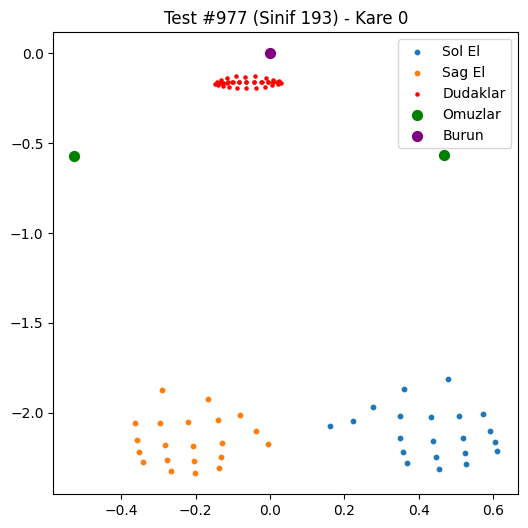

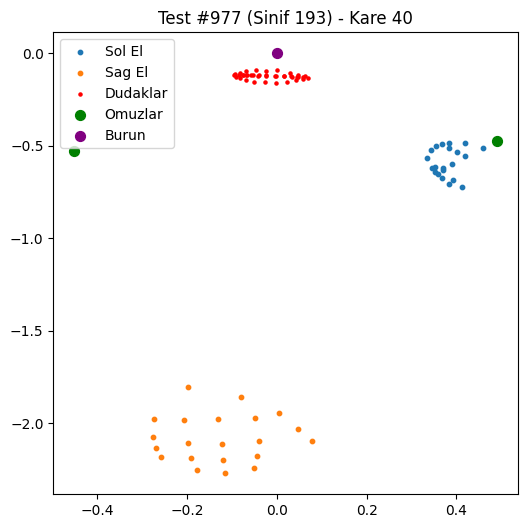

In [12]:
def plot_frame(data_frame, title="Normalize Edilmis Ornek Kare"):
    """Tek bir kareyi gorsellestirir. Indeksler: 0-20 Sol El, 21-41 Sag El, 42-81 Dudaklar, 82-84 Vucut Ref."""
    plt.figure(figsize=(6, 6))
    plt.scatter(data_frame[0:21, 0], -data_frame[0:21, 1], label='Sol El', s=10)
    plt.scatter(data_frame[21:42, 0], -data_frame[21:42, 1], label='Sag El', s=10)
    plt.scatter(data_frame[42:82, 0], -data_frame[42:82, 1], label='Dudaklar', s=5, c='red')
    plt.scatter(data_frame[-3:-1, 0], -data_frame[-3:-1, 1], label='Omuzlar', s=50, c='green')
    plt.scatter(data_frame[-1, 0], -data_frame[-1, 1], label='Burun', s=50, c='purple')
    plt.legend()
    plt.title(title)
    plt.show()

if X_test is not None and len(X_test) > 0:
    rand_idx = np.random.randint(0, len(X_test))
    print(f"Test Ornegi #{rand_idx}, Sinif: {y_test[rand_idx]}")
    plot_frame(X_test[rand_idx, 0, :, :], f"Test #{rand_idx} (Sinif {y_test[rand_idx]}) - Kare 0")
    plot_frame(X_test[rand_idx, 40, :, :], f"Test #{rand_idx} (Sinif {y_test[rand_idx]}) - Kare 40")
else:
    print("Gorsellestirme icin egitim verisi yukleniyor...")
    X_vis = np.load(os.path.join(OUTPUT_DIR, "X_train.npy"), mmap_mode='r')
    y_vis = np.load(os.path.join(OUTPUT_DIR, "y_train.npy"))
    rand_idx = np.random.randint(0, len(X_vis))
    print(f"Egitim Ornegi #{rand_idx}, Sinif: {y_vis[rand_idx]}")
    plot_frame(X_vis[rand_idx, 0, :, :], f"Egitim #{rand_idx} (Sinif {y_vis[rand_idx]}) - Kare 0")
    plot_frame(X_vis[rand_idx, 40, :, :], f"Egitim #{rand_idx} (Sinif {y_vis[rand_idx]}) - Kare 40")
    del X_vis, y_vis

## 10. Hizli Yukleme Testi

In [13]:
print("=" * 60)
print("Hizli Yukleme Testi")
print("=" * 60)

for split in SPLITS:
    x_path = os.path.join(OUTPUT_DIR, f"X_{split}.npy")
    y_path = os.path.join(OUTPUT_DIR, f"y_{split}.npy")
    meta_path = os.path.join(OUTPUT_DIR, f"metadata_{split}.csv")
    
    if not os.path.exists(x_path):
        print(f"UYARI: {split.upper()} dosyasi bulunamadi.")
        continue
    
    X = np.load(x_path, mmap_mode='r')
    y = np.load(y_path)
    meta = pd.read_csv(meta_path)
    
    print(f"\n[{split.upper()}]: X={X.shape}, y={y.shape}, meta={len(meta)} satir")
    print(f"   Sinifler: {len(np.unique(y))} benzersiz, aralik: {y.min()}-{y.max()}")
    
    assert X.shape[0] == y.shape[0] == len(meta), f"Boyut uyumsuzlugu!"
    assert X.shape == (y.shape[0], TARGET_FRAMES, NUM_SELECTED_POINTS, 3), f"Sekil hatasi!"
    print(f"   Tum kontroller basarili.")
    
    del X, y, meta

print(f"\n{'=' * 60}")
print("Islem tamamlandi. Veriler egitim defteri icin hazirdir.")
print(f"{'=' * 60}")

Hizli Yukleme Testi

[TRAIN]: X=(28130, 80, 85, 3), y=(28130,), meta=28130 satir
   Sinifler: 226 benzersiz, aralik: 0-225
   Tum kontroller basarili.

[VAL]: X=(4416, 80, 85, 3), y=(4416,), meta=4416 satir
   Sinifler: 226 benzersiz, aralik: 0-225
   Tum kontroller basarili.

[TEST]: X=(3739, 80, 85, 3), y=(3739,), meta=3739 satir
   Sinifler: 226 benzersiz, aralik: 0-225
   Tum kontroller basarili.

Islem tamamlandi. Veriler egitim defteri icin hazirdir.


In [14]:
# Son bellek temizligi
try:
    del X_test, y_test, paths_test, errfiles_test
except:
    pass
gc.collect()

print("Bellek temizligi tamamlandi.")
print(f"\nSonraki adim: Kaydedilen dosyalar Egitim Defterinde (03) kullanilacaktir.")
print(f"Cikti dizini: {OUTPUT_DIR}/")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"      {f}")

Bellek temizligi tamamlandi.

Sonraki adim: Kaydedilen dosyalar Egitim Defterinde (03) kullanilacaktir.
Cikti dizini: /kaggle/working/AUTSL_Full_Processed/
      X_test.npy
      X_train.npy
      X_val.npy
      metadata_test.csv
      metadata_train.csv
      metadata_val.csv
      y_test.npy
      y_train.npy
      y_val.npy
